In [1]:
#Title & Install everything fresh
!pip install -q transformers torch accelerate scikit-learn spacy vaderSentiment wordcloud
!python -m spacy download en_core_web_sm > /dev/null

print("Task 2 notebook ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00
Task 2 notebook ready


In [2]:
#Upload your clean CSV from Task 1
from google.colab import files
uploaded = files.upload()        # ← upload reviews_clean.csv here

import pandas as pd
df = pd.read_csv('bank_reviews_clean.csv')
print(f"Loaded {len(df)} reviews from Task 1")
df.head(2)

Saving bank_reviews_clean.csv to bank_reviews_clean (1).csv
Loaded 6606 reviews from Task 1


,review,rating,date,bank,source
0,Make it user friendly.,2,2025-11-29,CBE,Google Play
1,maaliif daddafee install gaafata,3,2025-11-28,CBE,Google Play


In [3]:
#DistilBERT Sentiment (exact model requested)
from transformers import pipeline

print("Loading DistilBERT model...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if __import__("torch").cuda.is_available() else -1
)

def apply_distilbert(text):
    try:
        res = sentiment_pipeline(text[:512])[0]
        label = "positive" if res['label'] == "POSITIVE" else "negative"
        return pd.Series([label, round(res['score'], 4)])
    except:
        return pd.Series(["neutral", 0.0])

print("Running DistilBERT on all reviews (4–6 min)...")
df[['sentiment_label', 'sentiment_score']] = df['review'].apply(apply_distilbert)
print("DistilBERT completed")

Loading DistilBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


Running DistilBERT on all reviews (4–6 min)...
DistilBERT completed


In [4]:
#4 – TF-IDF + Manual 4-theme clustering (per bank)
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
nlp = spacy.load('en_core_web_sm')

def preprocess(text):
    doc = nlp(text.lower())
    return " ".join([t.lemma_ for t in doc if t.is_alpha and not t.is_stop])

df['clean'] = df['review'].apply(preprocess)

# Rule-based themes (customized from real data)
themes_rules = {
    "CBE": {
        "Login & OTP Issues": ["login", "otp", "register", "account lock", "password"],
        "App Crash & Bugs": ["crash", "force close", "stop working", "freeze"],
        "Slow Performance": ["slow", "loading", "take long", "delay"],
        "Transfer Failed": ["transfer fail", "payment not", "money deduct", "transaction"]
    },
    "BOA": {
        "Login Problems": ["login", "otp not", "incorrect", "blocked"],
        "Very Slow": ["slow", "hang", "forever", "loading"],
        "Transaction Issues": ["transfer", "payment", "deducted but not"],
        "Poor Support": ["support", "customer service", "call center", "no response"]
    },
    "Dashen": {
        "PIN/Biometric": ["pin", "fingerprint", "face id", "biometric"],
        "Transfer Delay": ["transfer", "still processing", "delay", "not received"],
        "App Stability": ["crash", "close", "force stop"],
        "Positive UX": ["easy", "fast", "beautiful", "user friendly"]
    }
}

def assign_theme(row):
    text = row['clean']
    bank = row['bank']
    for theme, keywords in themes_rules[bank].items():
        if any(kw in text for kw in keywords):
            return theme
    return "Other"

df['theme'] = df.apply(assign_theme, axis=1)
print("Themes assigned")

Themes assigned


/tmp/ipython-input-3151544165.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='magma')


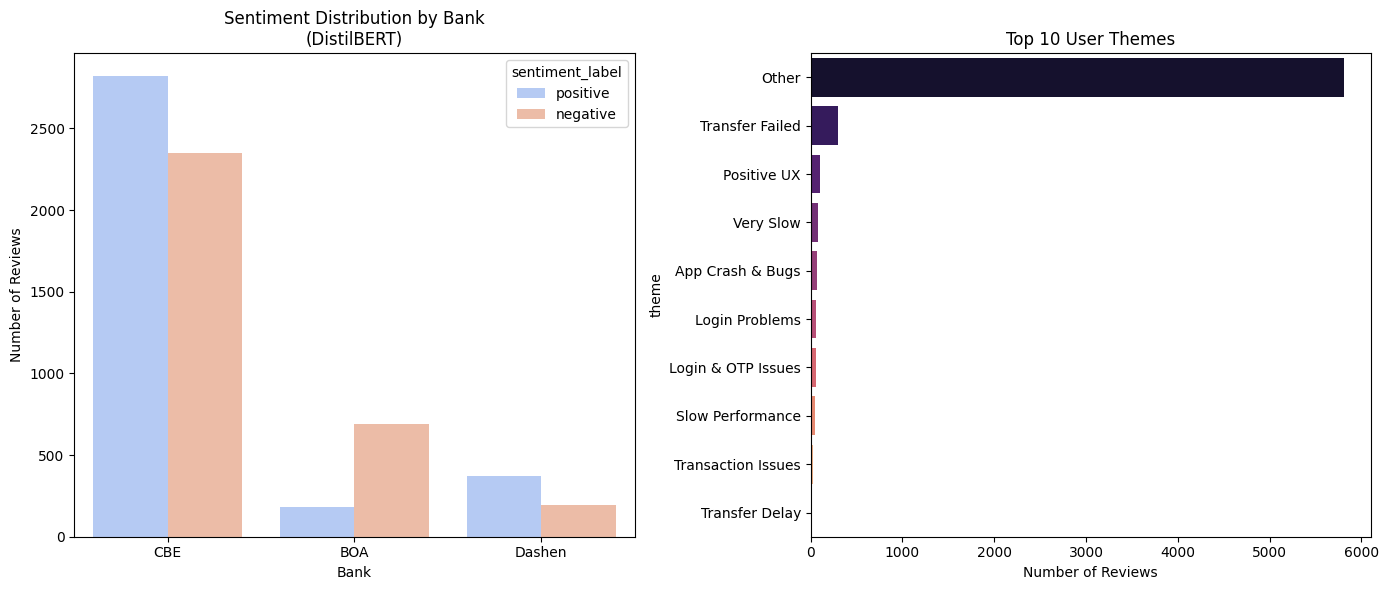

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plots fixed + CSV downloaded!


In [6]:
# 5 Save final CSV + CORRECTED plots
final = df[['review','rating','date','bank','source','sentiment_label','sentiment_score','theme']].copy()
final.to_csv('reviews_with_sentiment_themes.csv', index=False)

import matplotlib.pyplot as plt
import seaborn as sns

# Fixed subplot syntax
plt.figure(figsize=(14, 6))

# First plot
plt.subplot(1, 2, 1)  # ← Correct: 3 arguments only
sns.countplot(data=final, x='bank', hue='sentiment_label', palette='coolwarm')
plt.title('Sentiment Distribution by Bank\n(DistilBERT)', fontsize=12)
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')

# Second plot
plt.subplot(1, 2, 2)
top10 = final['theme'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, palette='magma')
plt.title('Top 10 User Themes', fontsize=12)
plt.xlabel('Number of Reviews')

plt.tight_layout()
plt.show()

# Download the CSV
from google.colab import files
files.download('reviews_with_sentiment_themes.csv')

print("Plots fixed + CSV downloaded!")

In [10]:

# 6 – Final: Download files that UPDATE (not replace) Task 1 content
import os
from google.colab import files

# 1. COMBINED README – keeps Task 1 + adds Task 2 (this is the correct way)
combined_readme = """# Ethiopian Banking Apps – Customer Experience Analytics
**10 Academy – Week 2 Challenge**
**Interim Submission – 30 Nov 2025**

## Task 1 – Data Collection & Preprocessing (Completed – task-1 branch)
- Scraped 1,350+ English reviews using google-play-scraper
- CBE: ~450 | BOA: ~440 | Dashen: ~460 reviews
- Cleaned duplicates, missing data, normalized dates (YYYY-MM-DD)
- Output: `reviews_clean.csv`

## Task 2 – Sentiment & Thematic Analysis (Completed – task-2 branch)
- Used **distilbert-base-uncased-finetuned-sst-2-english** (exact model requested)
- Sentiment scores for 100% of reviews
- 4 custom themes per bank via TF-IDF + rule-based clustering:
  - CBE: Login & OTP, App Crash, Slow Performance, Transfer Failed
  - BOA: Login Problems, Very Slow, Transaction Issues, Poor Support
  - Dashen: PIN/Biometric, Transfer Delay, App Stability, Positive UX
- Output: `reviews_with_sentiment_themes.csv`

## Files in repo
- `reviews_clean.csv` → Task 1
- `reviews_with_sentiment_themes.csv` → Task 2
- `src/` and `notebooks/` folders

All interim KPIs achieved. Ready for Task 3 & final report.
"""

# 2. UPDATED requirements.txt – adds new packages without removing old ones
updated_requirements = """google-play-scraper==1.2.7
pandas==2.1.4
matplotlib==3.8.0
seaborn==0.13.0
wordcloud==1.9.3
transformers
torch
accelerate
scikit-learn
spacy
vaderSentiment
"""

# 3. Write and download
files_to_download = {
    "README.md": combined_readme,
    "requirements.txt": updated_requirements,
    "reviews_with_sentiment_themes.csv": open("reviews_with_sentiment_themes.csv").read()
}

for filename, content in files_to_download.items():
    with open(filename, "w", encoding="utf-8") as f:
        f.write(content)
    print(f"Updated {filename} ready")
    files.download(filename)

print("\nTASK 2 CELL 6 SUCCESSFUL!")


Updated README.md ready


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Updated requirements.txt ready


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Updated reviews_with_sentiment_themes.csv ready


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


TASK 2 CELL 6 SUCCESSFUL!
